# 二、数据获取与特征工程

## 任务要求
1. **数据获取**：使用Tushare Pro获取沪深300成分股中10只股票的5年历史数据（包含：开盘价、收盘价、成交量、换手率）。
2. **特征计算**：计算MACD、RSI、布林带指标，并构建特征矩阵。

## 1. 准备工作
导入必要的库并配置Tushare Token。

In [1]:
import pandas as pd
import numpy as np
import tushare as ts

# 配置 Tushare Token (使用已有 Token)
ts.set_token('229e2c478deaef0ccf3030b42121cc7b5ba066dd3c9789b4835c943d')
pro = ts.pro_api()

# 选取10只沪深300成分股样本 (覆盖金融、消费、科技、医药、制造等行业)
stock_list = {
    '贵州茅台': '600519.SH',  # 白酒龙头
    '宁德时代': '300750.SZ',  # 新能源电池龙头
    '中国平安': '601318.SH',  # 保险龙头
    '招商银行': '600036.SH',  # 银行龙头
    '美的集团': '000333.SZ',  # 家电龙头
    '五粮液': '000858.SZ',    # 白酒
    '迈瑞医疗': '300760.SZ',  # 医疗器械龙头
    '恒瑞医药': '600276.SH',  # 创新药龙头
    '比亚迪': '002594.SZ',    # 新能源汽车龙头
    '长江电力': '600900.SH'   # 电力公用事业
}

## 2. 数据获取
获取过去5年的日线数据，包括OHLCV和换手率。

In [7]:
def get_stock_data_5y(stock_name, ts_code):
    print(f"正在获取 {stock_name} ({ts_code}) 的数据...")
    
    start_date = '20200101'
    end_date = '20251231'
    
    # 1. 获取基础日线行情 (Open, Close, Vol)
    # Tushare daily 接口包含: ts_code, trade_date, open, high, low, close, pre_close, change, pct_chg, vol, amount
    df_daily = pro.daily(ts_code=ts_code, start_date=start_date, end_date=end_date)
    
    # 2. 获取每日指标 (换手率 turnover_rate)
    # Tushare daily_basic 接口包含: turnover_rate, turnover_rate_f 等
    df_basic = pro.daily_basic(ts_code=ts_code, start_date=start_date, end_date=end_date, fields='ts_code,trade_date,turnover_rate')
    
    # 3. 合并数据
    if not df_daily.empty and not df_basic.empty:
        df = pd.merge(df_daily, df_basic, on=['ts_code', 'trade_date'], how='left')
        
        # 数据清洗与格式化
        df['trade_date'] = pd.to_datetime(df['trade_date'])
        df.set_index('trade_date', inplace=True)
        df.sort_index(inplace=True)
        
        # 保留指定字段
        # vol单位为手，turnover_rate单位为%
        df = df[['open', 'close', 'vol', 'turnover_rate']]
        return df
    else:
        print(f"{stock_name} 数据获取失败")
        return None

# 测试获取几只股票 (验证接口连通性)
test_targets = [('贵州茅台', '600519.SH'), ('宁德时代', '300750.SZ'), ('比亚迪', '002594.SZ')]

print("="*40)
print("开始进行数据获取测试...")
for name, code in test_targets:
    print(f"\n>>> 测试股票: {name}")
    test_df = get_stock_data_5y(name, code)
    if test_df is not None:
        print(f"获取成功! 数据行数: {len(test_df)}")
        print("数据预览 (Head 3):")
        print(test_df.head(3))
print("="*40)

开始进行数据获取测试...

>>> 测试股票: 贵州茅台
正在获取 贵州茅台 (600519.SH) 的数据...
获取成功! 数据行数: 1455
数据预览 (Head 3):
               open    close        vol  turnover_rate
trade_date                                            
2020-01-02  1128.00  1130.00  148099.16         1.1789
2020-01-03  1117.00  1078.56  130318.78         1.0374
2020-01-06  1070.86  1077.99   63414.78         0.5048

>>> 测试股票: 宁德时代
正在获取 宁德时代 (300750.SZ) 的数据...
获取成功! 数据行数: 1455
数据预览 (Head 3):
              open   close        vol  turnover_rate
trade_date                                          
2020-01-02  107.21  107.52  206115.89         1.7139
2020-01-03  107.52  109.55  180841.78         1.5038
2020-01-06  111.30  109.09  265002.00         2.2036

>>> 测试股票: 比亚迪
正在获取 比亚迪 (002594.SZ) 的数据...
获取成功! 数据行数: 1455
数据预览 (Head 3):
             open  close        vol  turnover_rate
trade_date                                        
2020-01-02  47.69  48.17  159345.70         1.3970
2020-01-03  48.20  48.04  129936.07         1.1391
2020-01-06  4

## 3. 特征计算 (Feature Engineering)
计算技术指标：
- **MACD (12, 26, 9)**: 趋势指标
- **RSI (14日)**: 动量/超买超卖指标
- **布林带 (20日, 2倍标准差)**: 波动率/均值回归指标

In [3]:
def calculate_features(df):
    if df is None: return None
    data = df.copy()
    
    # 1. MACD (12, 26, 9)
    # EMA_12
    exp12 = data['close'].ewm(span=12, adjust=False).mean()
    # EMA_26
    exp26 = data['close'].ewm(span=26, adjust=False).mean()
    # DIF
    data['MACD_DIF'] = exp12 - exp26
    # DEA (9)
    data['MACD_DEA'] = data['MACD_DIF'].ewm(span=9, adjust=False).mean()
    # MACD Histogram (柱状图)
    data['MACD_Hist'] = 2 * (data['MACD_DIF'] - data['MACD_DEA'])
    
    # 2. RSI (14日)
    delta = data['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI_14'] = 100 - (100 / (1 + rs))
    
    # 3. 布林带 (20日, 2*std)
    data['BOLL_MID'] = data['close'].rolling(window=20).mean()
    data['BOLL_STD'] = data['close'].rolling(window=20).std()
    data['BOLL_UP'] = data['BOLL_MID'] + 2 * data['BOLL_STD']
    data['BOLL_DN'] = data['BOLL_MID'] - 2 * data['BOLL_STD']
    
    # 清除计算前期的空值 (Rolling window产生的NaN)
    return data.dropna()

print("特征计算函数定义完成。")

特征计算函数定义完成。


## 4. 批量处理并保存
对选取的10只股票分别进行数据获取与特征计算，并将结果保存为 **CSV文件** 和 **Database (SQLite)**。

In [4]:
import os
import sqlite3
from IPython.display import display

# 创建保存目录 - 增加 "题目二" 标记
output_dir = '题目二_stock_features_data' 
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 数据库连接 - 增加 "题目二" 标记
db_path = '题目二_stock_features.db'
conn = sqlite3.connect(db_path)

results = {}

print("开始批量处理并保存数据 (题目二)...")

for name, code in stock_list.items():
    # 1. 获取数据
    raw_df = get_stock_data_5y(name, code)
    
    # 2. 计算特征
    if raw_df is not None:
        feature_df = calculate_features(raw_df)
        
        # 添加标识列，方便合并分析
        feature_df['ts_code'] = code
        feature_df['stock_name'] = name
        
        results[name] = feature_df
        
        # --- A. 保存到 CSV ---
        # 文件名: 题目二_stock_features_data/题目二_600519.SH_贵州茅台.csv
        file_name = f"题目二_{code}_{name}.csv"
        file_path = os.path.join(output_dir, file_name)
        # encoding='utf-8-sig' 用于解决中文乱码
        feature_df.to_csv(file_path, encoding='utf-8-sig')
        
        # --- B. 保存到 SQLite ---
        # 表名: feature_600519 (去除后缀)
        table_name = f"feature_{code.split('.')[0]}" 
        feature_df.to_sql(table_name, conn, if_exists='replace', index=True)
        
        print(f">>> {name} ({code}) 处理完成:")
        print(f"    - CSV已保存至: {file_path}")
        print(f"    - DB已保存至表: {table_name}")
        print(f"    - 矩阵尺寸: {feature_df.shape}")
        
        # --- C. 展示数据表 (数字表格) ---
        print(f"    - 数据预览 (最新5日):")
        display(feature_df.tail()) # 使用 display 展示 Pandas 表格
        print("-" * 60)

conn.close()
print(f"\n全部处理完成！\n数据库文件路径: {os.path.abspath(db_path)}\nCSV文件夹路径: {os.path.abspath(output_dir)}")

开始批量处理并保存数据 (题目二)...
正在获取 贵州茅台 (600519.SH) 的数据...
>>> 贵州茅台 (600519.SH) 处理完成:
    - CSV已保存至: 题目二_stock_features_data\题目二_600519.SH_贵州茅台.csv
    - DB已保存至表: feature_600519
    - 矩阵尺寸: (1436, 14)
    - 数据预览 (最新5日):


,open,close,vol,turnover_rate,MACD_DIF,MACD_DEA,MACD_Hist,RSI_14,BOLL_MID,BOLL_STD,BOLL_UP,BOLL_DN,ts_code,stock_name
trade_date,,,,,,,,,,,,,,
2025-12-25,1405.00,1414.17,23386.21,0.1868,-9.392004,-8.870264,-1.043479,43.086592,1421.2790,14.469881,1450.218762,1392.339238,600519.SH,贵州茅台
2025-12-26,1414.17,1414.13,17802.99,0.1422,-8.864860,-8.869183,0.008648,48.010894,1419.4605,12.792420,1445.045340,1393.875660,600519.SH,贵州茅台
2025-12-29,1414.13,1402.00,26308.10,0.2101,-9.318466,-8.959040,-0.718852,50.506497,1417.1605,11.456647,1440.073793,1394.247207,600519.SH,贵州茅台
2025-12-30,1401.00,1389.72,33791.94,0.2698,-10.547264,-9.276685,-2.541158,43.956755,1414.8450,12.103789,1439.052578,1390.637422,600519.SH,贵州茅台
2025-12-31,1390.00,1377.18,34765.63,0.2776,-12.390142,-9.899376,-4.981531,34.399928,1412.2490,14.261091,1440.771181,1383.726819,600519.SH,贵州茅台


------------------------------------------------------------
正在获取 宁德时代 (300750.SZ) 的数据...
>>> 宁德时代 (300750.SZ) 处理完成:
    - CSV已保存至: 题目二_stock_features_data\题目二_300750.SZ_宁德时代.csv
    - DB已保存至表: feature_300750
    - 矩阵尺寸: (1436, 14)
    - 数据预览 (最新5日):


,open,close,vol,turnover_rate,MACD_DIF,MACD_DEA,MACD_Hist,RSI_14,BOLL_MID,BOLL_STD,BOLL_UP,BOLL_DN,ts_code,stock_name
trade_date,,,,,,,,,,,,,,
2025-12-25,374.21,373.01,203431.44,0.4779,-1.880377,-0.635144,-2.490466,38.224956,380.9955,6.754868,394.505237,367.485763,300750.SZ,宁德时代
2025-12-26,372.96,374.43,257236.89,0.6044,-2.018460,-0.911807,-2.213306,36.370493,381.0570,6.685401,394.427801,367.686199,300750.SZ,宁德时代
2025-12-29,374.00,369.31,241240.72,0.5668,-2.512075,-1.231861,-2.560429,36.255639,380.3740,7.160563,394.695127,366.052873,300750.SZ,宁德时代
2025-12-30,367.10,369.20,190308.21,0.4471,-2.878958,-1.561280,-2.635356,39.267101,379.8300,7.584794,394.999587,364.660413,300750.SZ,宁德时代
2025-12-31,369.79,367.26,160265.97,0.3765,-3.288352,-1.906695,-2.763314,30.847876,379.3890,8.056072,395.501144,363.276856,300750.SZ,宁德时代


------------------------------------------------------------
正在获取 中国平安 (601318.SH) 的数据...
>>> 中国平安 (601318.SH) 处理完成:
    - CSV已保存至: 题目二_stock_features_data\题目二_601318.SH_中国平安.csv
    - DB已保存至表: feature_601318
    - 矩阵尺寸: (1436, 14)
    - 数据预览 (最新5日):


...

------------------------------------------------------------
正在获取 比亚迪 (002594.SZ) 的数据...
>>> 比亚迪 (002594.SZ) 处理完成:
    - CSV已保存至: 题目二_stock_features_data\题目二_002594.SZ_比亚迪.csv
    - DB已保存至表: feature_002594
    - 矩阵尺寸: (1436, 14)
    - 数据预览 (最新5日):


,open,close,vol,turnover_rate,MACD_DIF,MACD_DEA,MACD_Hist,RSI_14,BOLL_MID,BOLL_STD,BOLL_UP,BOLL_DN,ts_code,stock_name
trade_date,,,,,,,,,,,,,,
2025-12-25,94.43,94.84,182201.63,0.5225,-0.943333,-1.111472,0.336278,44.288577,95.3640,0.949479,97.262957,93.465043,002594.SZ,比亚迪
2025-12-26,95.28,100.01,1020958.95,2.9277,-0.466458,-0.982469,1.032022,61.917808,95.6060,1.404974,98.415948,92.796052,002594.SZ,比亚迪
2025-12-29,100.50,100.21,519166.96,1.4888,-0.071568,-0.800289,1.457442,64.615385,95.8280,1.742492,99.312985,92.343015,002594.SZ,比亚迪
2025-12-30,99.26,99.75,318756.38,0.9141,0.201939,-0.599843,1.603566,61.452514,95.9845,1.946039,99.876578,92.092422,002594.SZ,比亚迪
2025-12-31,99.98,97.72,402858.87,1.1552,0.251987,-0.429477,1.362929,54.624457,96.1180,1.969992,100.057985,92.178015,002594.SZ,比亚迪


------------------------------------------------------------
正在获取 长江电力 (600900.SH) 的数据...
>>> 长江电力 (600900.SH) 处理完成:
    - CSV已保存至: 题目二_stock_features_data\题目二_600900.SH_长江电力.csv
    - DB已保存至表: feature_600900
    - 矩阵尺寸: (1425, 14)
    - 数据预览 (最新5日):


,open,close,vol,turnover_rate,MACD_DIF,MACD_DEA,MACD_Hist,RSI_14,BOLL_MID,BOLL_STD,BOLL_UP,BOLL_DN,ts_code,stock_name
trade_date,,,,,,,,,,,,,,
2025-12-25,27.63,27.64,300805.76,0.1253,-0.124698,-0.088527,-0.072341,37.125749,27.9460,0.203661,28.353322,27.538678,600900.SH,长江电力
2025-12-26,27.61,27.64,482593.39,0.2010,-0.129869,-0.096796,-0.066147,42.176871,27.9290,0.214572,28.358144,27.499856,600900.SH,长江电力
2025-12-29,27.64,27.52,689033.36,0.2870,-0.142013,-0.105839,-0.072348,34.899329,27.9015,0.230224,28.361947,27.441053,600900.SH,长江电力
2025-12-30,27.50,27.32,724247.00,0.3017,-0.165864,-0.117844,-0.096039,32.298137,27.8545,0.248416,28.351331,27.357669,600900.SH,长江电力
2025-12-31,27.35,27.19,742930.24,0.3095,-0.193030,-0.132881,-0.120298,30.409357,27.8005,0.269805,28.340109,27.260891,600900.SH,长江电力


------------------------------------------------------------

全部处理完成！
数据库文件路径: e:\airesearch\ecofinal\题目二_stock_features.db
CSV文件夹路径: e:\airesearch\ecofinal\题目二_stock_features_data


## 5. 数据透视与可视化
选取典型股票（如贵州茅台），通过打印特征矩阵的头部和尾部数据，并绘制包含 **布林带**、**MACD**、**RSI** 的组合分析图，直观展示特征工程的产出结果。


>>> 贵州茅台 特征矩阵数据概览 (N=1436)
              close       vol   MACD_DIF  MACD_Hist     RSI_14      BOLL_UP  \
trade_date                                                                    
2020-02-06  1071.00  47171.21 -18.952203  -7.827403  42.791523  1147.448535   
2020-02-07  1076.00  31278.71 -16.957064  -3.069701  41.514785  1141.122233   
2020-02-10  1066.49  30533.42 -15.959311  -0.859356  36.425148  1140.927176   
2020-02-11  1098.00  47917.93 -12.482105   4.876045  47.933703  1142.337839   
2020-02-12  1097.27  28125.43  -9.673786   8.394147  46.675020  1142.601646   
2025-12-25  1414.17  23386.21  -9.392004  -1.043479  43.086592  1450.218762   
2025-12-26  1414.13  17802.99  -8.864860   0.008648  48.010894  1445.045340   
2025-12-29  1402.00  26308.10  -9.318466  -0.718852  50.506497  1440.073793   
2025-12-30  1389.72  33791.94 -10.547264  -2.541158  43.956755  1439.052578   
2025-12-31  1377.18  34765.63 -12.390142  -4.981531  34.399928  1440.771181   

                BOLL_DN

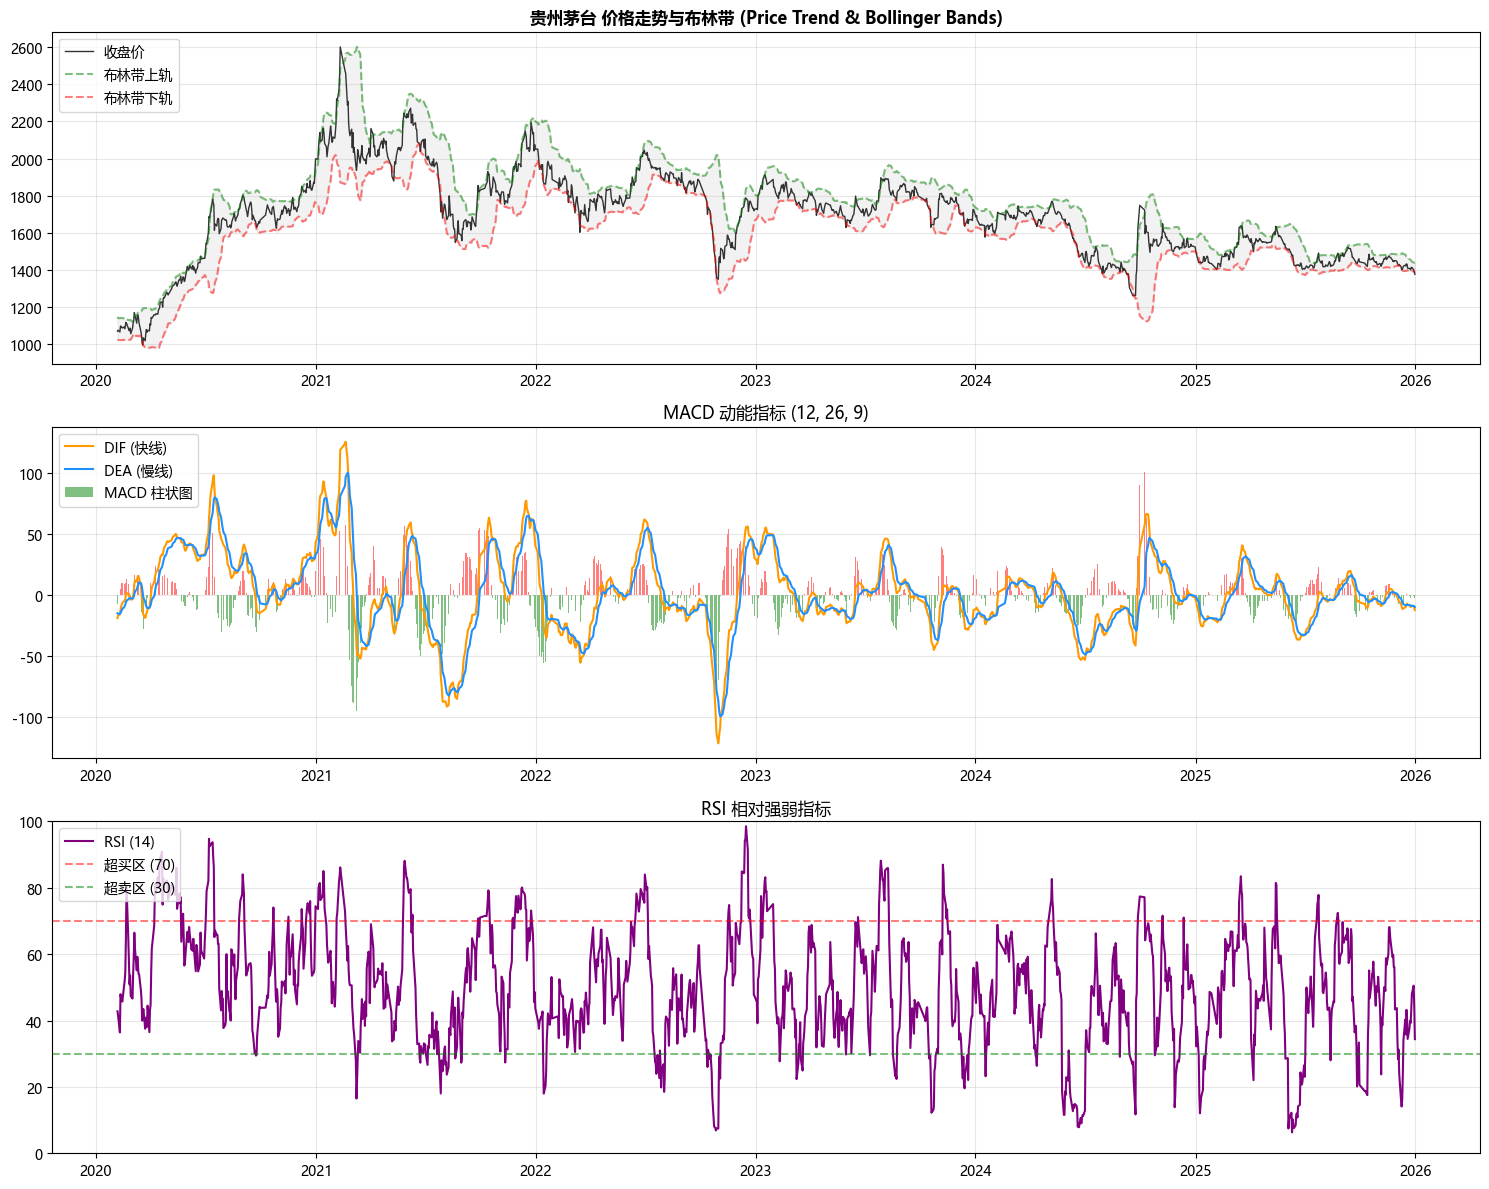

In [5]:
import matplotlib.pyplot as plt
import matplotlib

# 设置中文字体，解决中文显示乱码问题
# 尝试多种常见的中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示为方块的问题

# 选取 "贵州茅台" 作为可视化展示样本
sample_name = '贵州茅台'

if sample_name in results:
    df_vis = results[sample_name]
    
    # 1. 展示更多数据细节 (前5行 + 后5行)
    print(f"\n{'='*30}\n>>> {sample_name} 特征矩阵数据概览 (N={len(df_vis)})\n{'='*30}")
    
    # 拼接头部和尾部
    display_df = pd.concat([df_vis.head(5), df_vis.tail(5)])
    
    # 选取关键列进行展示，避免列太多看不清
    key_cols = ['close', 'vol', 'MACD_DIF', 'MACD_Hist', 'RSI_14', 'BOLL_UP', 'BOLL_DN']
    print(display_df[key_cols])
    
    # 2. 绘制可视化图表
    plt.figure(figsize=(15, 12))
    
    # 子图1: 价格与布林带
    ax1 = plt.subplot(311)
    ax1.plot(df_vis.index, df_vis['close'], label='收盘价', color='#333333', linewidth=1)
    ax1.plot(df_vis.index, df_vis['BOLL_UP'], label='布林带上轨', color='green', linestyle='--', alpha=0.5)
    ax1.plot(df_vis.index, df_vis['BOLL_DN'], label='布林带下轨', color='red', linestyle='--', alpha=0.5)
    ax1.fill_between(df_vis.index, df_vis['BOLL_UP'], df_vis['BOLL_DN'], color='gray', alpha=0.1)
    ax1.set_title(f'{sample_name} 价格走势与布林带 (Price Trend & Bollinger Bands)', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # 子图2: MACD
    ax2 = plt.subplot(312, sharex=ax1)
    ax2.plot(df_vis.index, df_vis['MACD_DIF'], label='DIF (快线)', color='#ff9900')
    ax2.plot(df_vis.index, df_vis['MACD_DEA'], label='DEA (慢线)', color='#1e90ff')
    # 柱状图配色: 红涨绿跌
    bar_colors = np.where(df_vis['MACD_Hist'] >= 0, 'red', 'green')
    ax2.bar(df_vis.index, df_vis['MACD_Hist'], color=bar_colors, alpha=0.5, label='MACD 柱状图')
    ax2.set_title('MACD 动能指标 (12, 26, 9)', fontsize=12)
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

    # 子图3: RSI
    ax3 = plt.subplot(313, sharex=ax1)
    ax3.plot(df_vis.index, df_vis['RSI_14'], label='RSI (14)', color='purple')
    ax3.axhline(70, color='red', linestyle='--', alpha=0.5, label='超买区 (70)')
    ax3.axhline(30, color='green', linestyle='--', alpha=0.5, label='超卖区 (30)')
    ax3.set_title('RSI 相对强弱指标', fontsize=12)
    ax3.set_ylim(0, 100)
    ax3.legend(loc='upper left')
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

else:
    print(f"未找到 {sample_name} 的结果，请确保之前的数据获取步骤已完成。")

## 6. 批量生成特征矩阵图表 (Batch Feature Matrix Visualization)

将对所有 10 只股票生成以下图表并保存至 `stock_analysis_plots` 文件夹：
1. **趋势与指标图**: 包含 K线(收盘价)、布林带、MACD、RSI。
2. **特征矩阵热力图**: 展示标准化后的多维特征分布。

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 创建保存目录 (包含图片和数据表) - 增加 "题目二" 标记
plot_dir = '题目二_stock_analysis_plots'
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

print(f"开始生成所有 10 只股票的特征矩阵图表及数据表，保存在: {plot_dir} ...\n")
# 设置绘图风格和字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

for name, df_vis in results.items():
    code = stock_list[name]
    
    # --- 1. 绘制并保存 趋势与指标图 (Trend & Indicators) ---
    plt.figure(figsize=(15, 12))
    
    # 子图1: 价格与布林带
    ax1 = plt.subplot(311)
    ax1.plot(df_vis.index, df_vis['close'], label='收盘价', color='#333333', linewidth=1)
    ax1.plot(df_vis.index, df_vis['BOLL_UP'], label='布林带上轨', color='green', linestyle='--', alpha=0.5)
    ax1.plot(df_vis.index, df_vis['BOLL_DN'], label='布林带下轨', color='red', linestyle='--', alpha=0.5)
    ax1.fill_between(df_vis.index, df_vis['BOLL_UP'], df_vis['BOLL_DN'], color='gray', alpha=0.1)
    ax1.set_title(f'{name} ({code}) 价格走势与布林带', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # 子图2: MACD
    ax2 = plt.subplot(312, sharex=ax1)
    ax2.plot(df_vis.index, df_vis['MACD_DIF'], label='DIF', color='#ff9900')
    ax2.plot(df_vis.index, df_vis['MACD_DEA'], label='DEA', color='#1e90ff')
    bar_colors = np.where(df_vis['MACD_Hist'] >= 0, 'red', 'green')
    ax2.bar(df_vis.index, df_vis['MACD_Hist'], color=bar_colors, alpha=0.5, label='MACD Hist')
    ax2.set_title('MACD 动能指标', fontsize=12)
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)

    # 子图3: RSI
    ax3 = plt.subplot(313, sharex=ax1)
    ax3.plot(df_vis.index, df_vis['RSI_14'], label='RSI (14)', color='purple')
    ax3.axhline(70, color='red', linestyle='--', alpha=0.5)
    ax3.axhline(30, color='green', linestyle='--', alpha=0.5)
    ax3.set_title('RSI 相对强弱指标', fontsize=12)
    ax3.set_ylim(0, 100)
    ax3.legend(loc='upper left')
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # 增加 "题目二" 前缀
    trend_filename = f"{plot_dir}/题目二_{code}_{name}_trend.png"
    plt.savefig(trend_filename)
    plt.close() # 关闭画布，释放内存

    # --- 2. 绘制并保存 特征矩阵热力图 & 数据表 (Feature Matrix Heatmap & Table) ---
    plt.figure(figsize=(18, 9))
    
    # 数据标准化
    df_numeric = df_vis.select_dtypes(include=[np.number])
    df_scaled = (df_numeric - df_numeric.mean()) / df_numeric.std()
    
    # 截取最近 50 个交易日
    df_scaled_subset = df_scaled.tail(50)
    
    # --- 保存标准化后的特征矩阵数据表 (增加 "题目二" 前缀) ---
    matrix_csv_filename = f"{plot_dir}/题目二_{code}_{name}_matrix_zscore.csv"
    df_scaled.to_csv(matrix_csv_filename, encoding='utf-8-sig') # 保存完整时间段的标准化数据

    # 绘制热力图
    # sns.heatmap 自动处理颜色映射
    ax = sns.heatmap(df_scaled_subset.T, 
                     cmap='RdBu_r', 
                     center=0,
                     cbar_kws={'label': 'Z-Score'},
                     xticklabels=5)
    
    plt.title(f'{name} ({code}) 特征矩阵热力图', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('交易日期', fontsize=12)
    plt.ylabel('特征指标', fontsize=12)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    # 增加 "题目二" 前缀
    matrix_filename = f"{plot_dir}/题目二_{code}_{name}_matrix.png"
    plt.savefig(matrix_filename)
    plt.close() 
    
    print(f"  [√] {name}: \n      - 走势图: {trend_filename}\n      - 矩阵图: {matrix_filename}\n      - 数据表: {matrix_csv_filename}")

print("\n所有图表及数据表生成完毕！可以打开 题目二_stock_analysis_plots 文件夹查看。")

开始生成所有 10 只股票的特征矩阵图表及数据表，保存在: 题目二_stock_analysis_plots ...

  [√] 贵州茅台: 
      - 走势图: 题目二_stock_analysis_plots/题目二_600519.SH_贵州茅台_trend.png
      - 矩阵图: 题目二_stock_analysis_plots/题目二_600519.SH_贵州茅台_matrix.png
      - 数据表: 题目二_stock_analysis_plots/题目二_600519.SH_贵州茅台_matrix_zscore.csv
  [√] 宁德时代: 
      - 走势图: 题目二_stock_analysis_plots/题目二_300750.SZ_宁德时代_trend.png
      - 矩阵图: 题目二_stock_analysis_plots/题目二_300750.SZ_宁德时代_matrix.png
      - 数据表: 题目二_stock_analysis_plots/题目二_300750.SZ_宁德时代_matrix_zscore.csv
  [√] 中国平安: 
      - 走势图: 题目二_stock_analysis_plots/题目二_601318.SH_中国平安_trend.png
      - 矩阵图: 题目二_stock_analysis_plots/题目二_601318.SH_中国平安_matrix.png
      - 数据表: 题目二_stock_analysis_plots/题目二_601318.SH_中国平安_matrix_zscore.csv
  [√] 招商银行: 
      - 走势图: 题目二_stock_analysis_plots/题目二_600036.SH_招商银行_trend.png
      - 矩阵图: 题目二_stock_analysis_plots/题目二_600036.SH_招商银行_matrix.png
      - 数据表: 题目二_stock_analysis_plots/题目二_600036.SH_招商银行_matrix_zscore.csv
  [√] 美的集团: 
      - 走势图: 题目二_stock_analysis_plo